**UNIVERSIDAD NACIONAL DE ASUNCIÓN**

**FACULTAD DE INGENIERÍA**

# **ROBÓTICA I**

TRABAJO PRÁCTICO FINAL 2026S2

## **"Línea de control de calidad y empaquetado de medicamentos en tabletas"**

---
### **ESTACIÓN [ 2 ]:** [ Q control: Detección y Colocación ]

**Grupo [E2]:**

*   Héctor Dejesús Velázquez Ojeda
*   Mathias Ramón Aguilar Delvalle
*   Victoria Carolina Paredes Frutos
*   Francisco Ramón González Galeano

**ENTREGA [5] :** [Demo: Control en lazo abierto]

**Fecha:** [26/09/2026]

**Versión:** [v1.0]

---
### **1. Control de motores de lazo abierto.**

#### 1.1 Objetivo

Caracterizar en **lazo abierto** los dos motores de la estación, el **motor base** y el **motor de la articulación**: aplicar una señal PWM conocida, medir con el encoder la respuesta del eje de salida **sin corregir nada** y obtener de las mediciones los datos para diseñar el control en lazo cerrado de la próxima entrega:

- la **zona muerta** (PWM mínimo con el que el motor gira) y el PWM de **arranque desde parado**;
- la **ganancia estática** $K$ (rpm de salida por cada % de PWM) y la velocidad máxima;
- la **constante de tiempo** $\tau$ del modelo de primer orden $G(s) = \dfrac{K}{\tau s + 1}$;
- la **simetría** entre los dos sentidos de giro y el efecto de una **carga** en el eje.

#### 1.2 Lazo abierto: ventajas y desventajas

En lazo abierto el controlador fija el PWM y no mira el resultado. En todas las demos el encoder **solo mide** (para graficar y calcular parámetros); su lectura no modifica el PWM.

- **Ventajas:** simplicidad, baja latencia, pocos componentes y bajo costo. Sirve cuando la precisión no es crítica o cuando la dinámica es conocida y las perturbaciones son pequeñas. Es además el primer paso para identificar el modelo del motor.
- **Desventajas:** no compensa perturbaciones ni errores del modelo. Las mediciones de esta entrega lo muestran: con **carga**, el mismo PWM de 50 % da **~21 rpm menos** en el motor base, y el PWM de arranque sube de ~16 % a 25 %. Tampoco compensa la fricción estática, las variaciones de la tensión de la fuente ni la caída de tensión del driver. La posición se acumula con error (deriva).

#### 1.3 Motores evaluados

| | **Motor base** | **Motor articulación** |
|---|---|---|
| Motor | 36GP-555, 12 V, 160 rpm, reductora planetaria **50:1**, eje de 8 mm | 5840-31ZY, 12 V, 160 rpm, reductor de **tornillo sin fin** (autobloqueante), 100 kg·cm |
| Driver | **IBT-2** (doble BTS7960, MOSFET, 43 A) | **L298N** (bipolar, 2 A por canal) |
| Encoder | Hall en el eje del motor, 16 PPR → **3200 cuentas por vuelta de salida** (x4) | Externo **38S6G5-B-G24N** en el eje de salida, 1000 PPR → **4000 cuentas por vuelta** (x4) |
| Controlador | ESP32-S3 (Freenove N16R8) | ESP32-WROOM-32D (DevKit con CH340) |
| PWM | 20 kHz, 10 bits | 1 kHz, 10 bits, modo **Freno** (PWM en IN1/IN2) |
| Proyecto | `06-motor-36gp555` y `07-motor-rampa-vueltas` | `08-motor-5840-l298n` |

En los dos casos el encoder se lee con el **contador de pulsos por hardware (PCNT)** del ESP32, en cuadratura x4: no pierde pulsos aunque el motor gire rápido y no carga al procesador con interrupciones.

#### 1.4 Pruebas realizadas (demos)

| Demo | Motor | Qué se hace | Qué se obtiene |
|---|---|---|---|
| **Barrido** (comando `a`) | Base | PWM de 10 a 100 % en pasos de 10 %, adelante y atrás; en cada paso espera 2 s y mide 1 s | Curva PWM–velocidad, $K$, zona muerta, simetría |
| **Escalón** (`e50`) | Base | Desde parado, PWM de 0 a 50 % sin rampa; registro cada 10 ms durante 3 s | $\tau$, tiempo de subida, velocidad final |
| **Perfil en escalera** (`p`) | Base y articulación | +20, +40, +60, +80, +100 % (5 s cada uno), freno hasta que el motor se detiene, y lo mismo hacia atrás; registro cada 10 ms | Posición, velocidad, $K$, zona muerta y $\tau$ por nivel; modelo $G(s)$ |
| **Rampa por vueltas** (`r 3 3`) | Base | PWM de 0 a 100 % en 3 s; termina al completar 3 vueltas de salida; **sin carga y con carga** | PWM de arranque, PWM por vuelta, efecto de la carga |

Las demos son la misma idea que la Demo 2 de la versión anterior de esta entrega (escalones de PWM en ambos sentidos con registro de la posición), con el análisis en Python en lugar de MATLAB y con estas diferencias:

- entre el tramo positivo y el negativo el motor **frena y espera a estar quieto**: nunca se invierte el sentido con el motor girando;
- **protecciones**: rampa de 50 %/s en el modo manual, corte por atasco (PWM alto y el encoder no avanza durante 1 s), comandos bloqueados si falla la inicialización del PWM o del encoder;
- el script de la PC manda el comando por el puerto serie, guarda el CSV y los gráficos en `resultados/` (con fecha y hora) y calcula los parámetros automáticamente.

---
### **2. Lista de materiales**

#### 2.1 Software

* **VS Code + PlatformIO** (plataforma `espressif32`, framework Arduino, core 2.0.17): compilación y carga del firmware.
* **Python 3** con `pyserial`, `numpy`, `matplotlib` y `scipy`: scripts `tools/graficar.py` y `tools/rampa.py` (ejecutan la prueba por el puerto serie, guardan CSV y PNG y calculan los parámetros).
* **Git + GitHub**: control de versiones (repositorio `pruebas-esp32`).
* **Ubuntu 24.04**.
* Asistentes de IA: **Claude Code** (escritura del código) y **Codex** (revisión del código).

#### 2.2 Hardware

| Cant. | Componente | Uso |
|---|---|---|
| 1 | ESP32-S3-WROOM-1 **N16R8** (Freenove) + breakout Freenove v1.2 | Controlador del motor base |
| 1 | **ESP32-WROOM-32D** (DevKit con USB-serie CH340) | Controlador del motor articulación |
| 1 | Motor **36GP-555** 12 V, 160 rpm, reductora 50:1, encoder Hall 16 PPR (placa SCX-555) | Motor base |
| 1 | Motor **5840-31ZY** 12 V, 160 rpm, sin fin, 100 kg·cm | Motor articulación |
| 1 | Módulo **IBT-2** (2 × BTS7960, 6–27 V, 43 A) | Driver del motor base |
| 1 | Módulo **L298N** (5–35 V, 2 A por canal) | Driver del motor articulación |
| 1 | Encoder incremental **38S6G5-B-G24N**, 1000 PPR, A/B, NPN colector abierto, 5–24 V | Posición de la salida del 5840-31ZY |
| 1 | Acople flexible (eje de 6 mm) | Une el encoder al eje de salida del 5840-31ZY |
| 1 | Fuente 12 V / 3 A | Alimentación del motor base (primeras pruebas) |
| 1 | Fuente de laboratorio **APS3005SI** (0–30 V, 0–5 A) | 12 V con límite de 3 A (base) y 2 A (articulación) |
| 2 | Cables USB | Programación y datos hacia la PC |
| 3 | Resistencias de 10 kΩ | Pull-down de R_EN, L_EN y ENA (**recomendadas, pendientes de colocar**) |
| – | Cables jumper, multímetro | Conexiones y verificaciones |
| – | [Completar: carga usada en la prueba con carga] | Rampa con carga del motor base |

#### 2.3 Montaje y conexiones

##### Motor base: 36GP-555 + IBT-2 + ESP32-S3

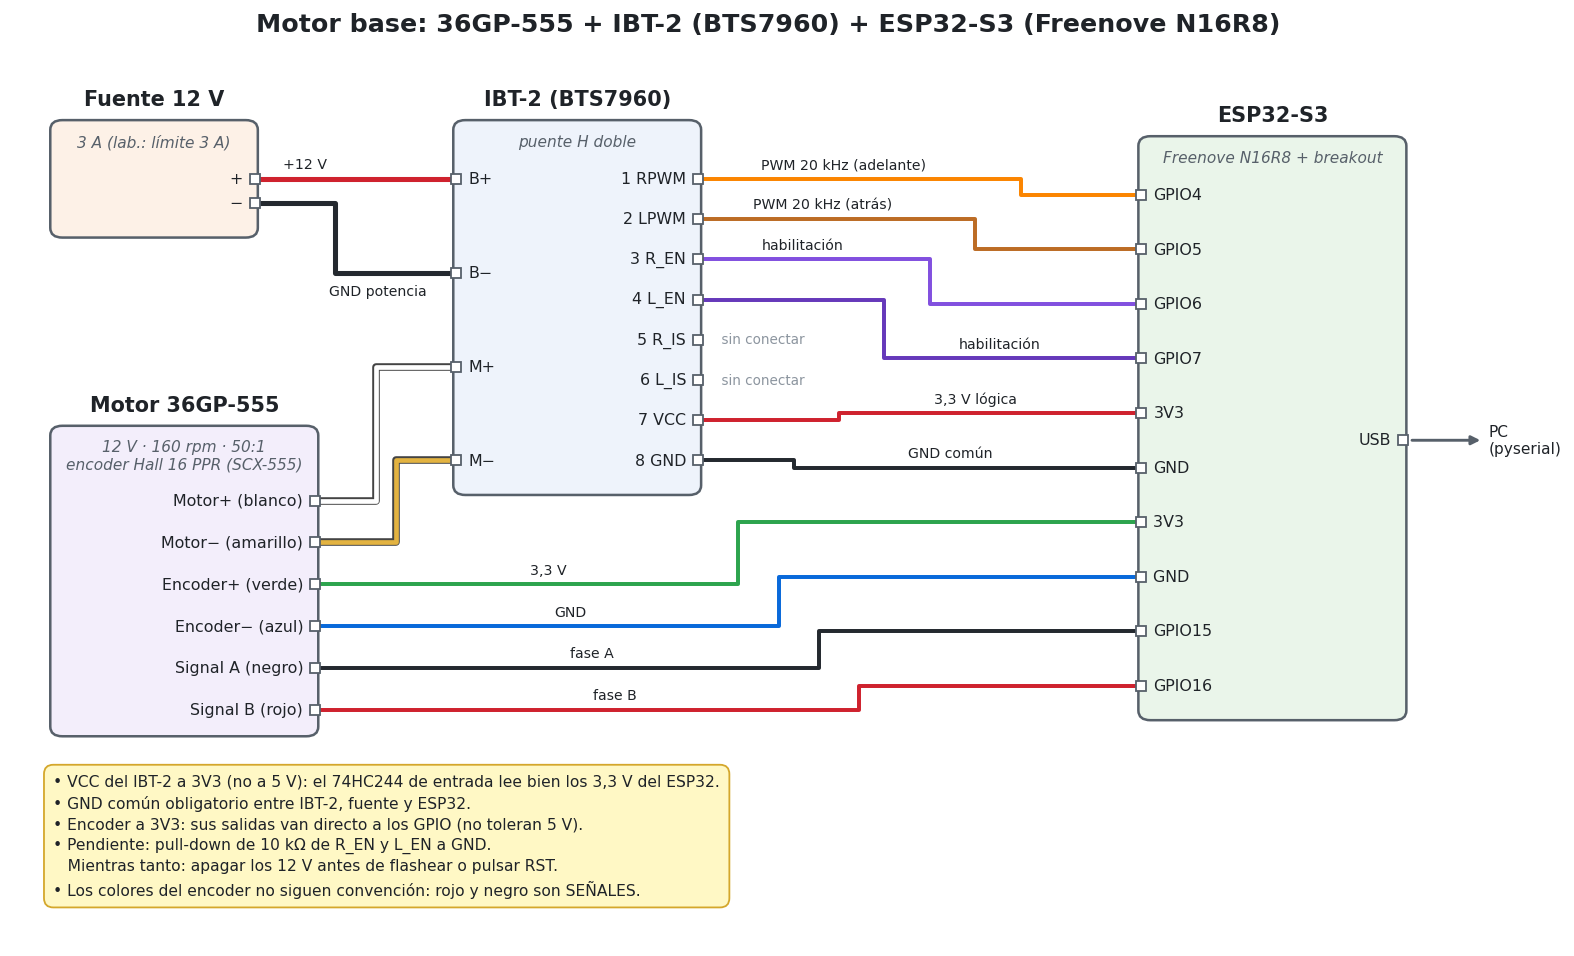

<p align="center"><b>Fig. 1.</b> Conexiones del motor base. Los colores de los cables del motor son los reales de la placa del encoder SCX-555.</p>

| Origen | Destino | Función |
|---|---|---|
| Fuente +12 V / − | IBT-2 B+ / B− | Potencia del motor |
| Motor+ (blanco) / Motor− (amarillo) | IBT-2 M+ / M− | Bornes del motor |
| GPIO4 | IBT-2 RPWM | PWM hacia adelante (20 kHz) |
| GPIO5 | IBT-2 LPWM | PWM hacia atrás (20 kHz) |
| GPIO6 / GPIO7 | IBT-2 R_EN / L_EN | Habilitación de cada medio puente |
| 3V3 / GND | IBT-2 VCC / GND | Lógica del módulo y **GND común** |
| 3V3 / GND | Encoder+ (verde) / Encoder− (azul) | Alimentación del encoder |
| GPIO15 / GPIO16 | Signal A (negro) / Signal B (rojo) | Fases del encoder |
| — | IBT-2 R_IS / L_IS | Sin conectar (sensado de corriente) |

- **VCC del IBT-2 a 3,3 V (no a 5 V):** ese pin alimenta el 74HC244 de las entradas; a 5 V necesitaría ~3,15 V para leer un "1" y el ESP32 da 3,3 V (al límite). El motor sigue recibiendo los 12 V por B+.
- **Encoder a 3,3 V:** sus salidas van directo a los GPIO, que no toleran 5 V.
- **Colores del encoder:** no siguen ninguna convención (el rojo y el negro son **señales**). Guiarse por la serigrafía de la placa y verificar con el multímetro antes de conectar.
- Los GPIO elegidos no chocan con el IMU (8/9), el GPS (41/42) ni el lidar (14/21), que se usan en la misma placa.

##### Motor articulación: 5840-31ZY + L298N + encoder 38S6G5 + ESP32-WROOM-32D

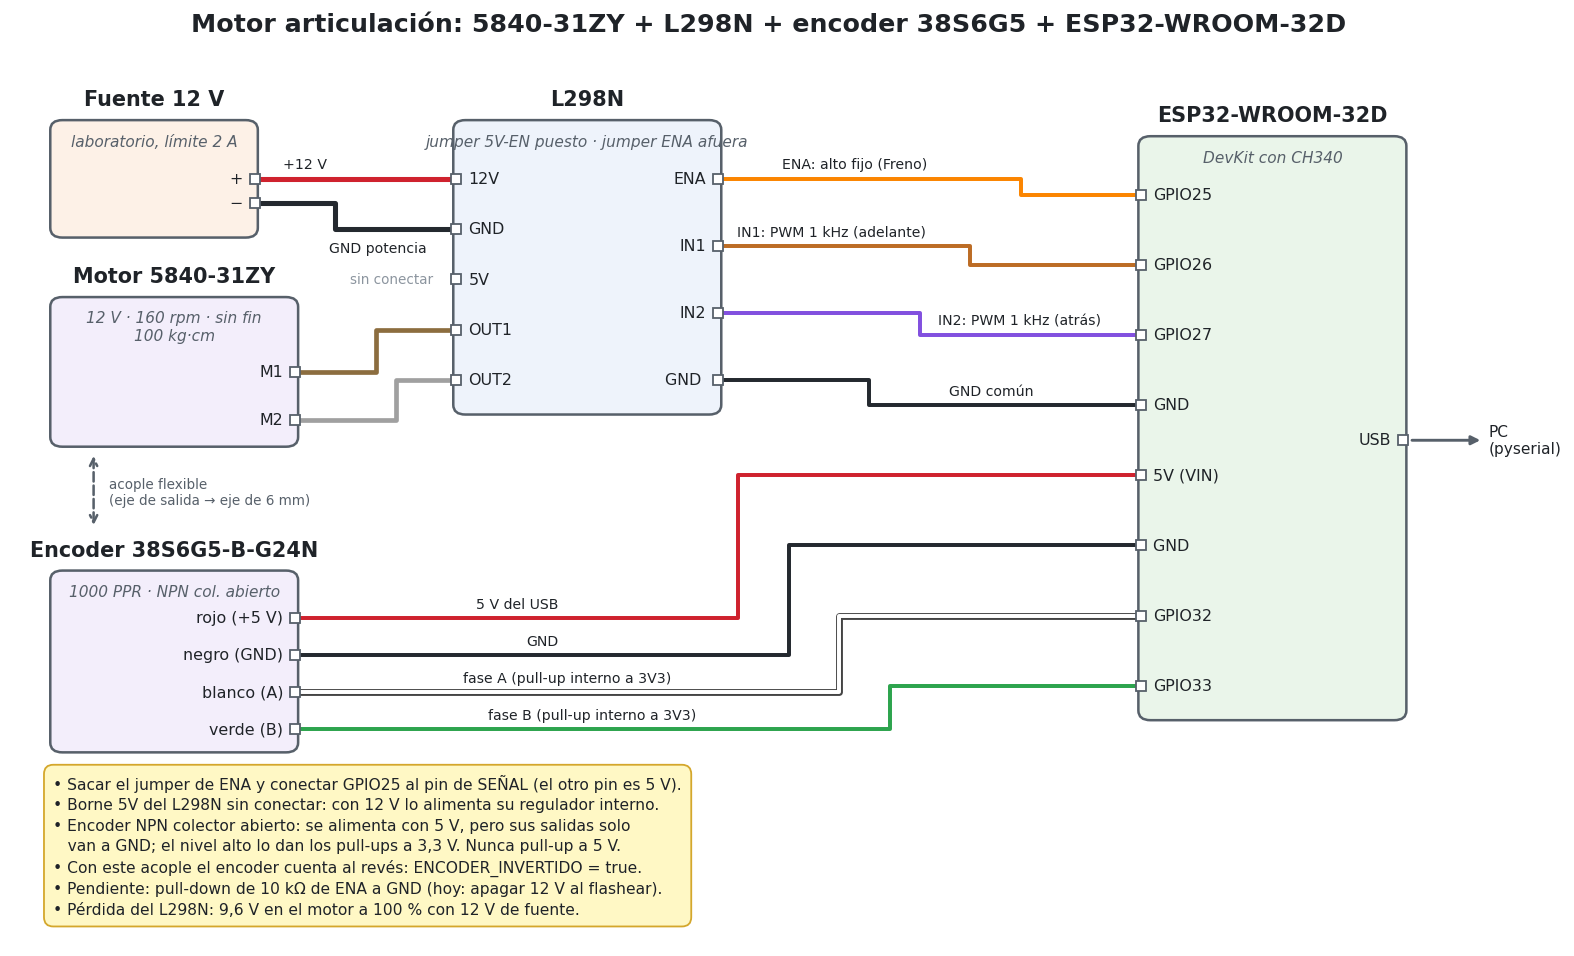

<p align="center"><b>Fig. 2.</b> Conexiones del motor de la articulación.</p>

| Origen | Destino | Función |
|---|---|---|
| Fuente +12 V / − | L298N 12V / GND | Potencia (límite de la fuente: 2 A) |
| Motor (2 cables) | L298N OUT1 / OUT2 | Bornes del motor (el orden solo cambia el sentido) |
| GPIO25 | L298N ENA (pin de señal, **jumper afuera**) | Alto fijo en modo Freno |
| GPIO26 / GPIO27 | L298N IN1 / IN2 | PWM de 1 kHz: adelante / atrás |
| GND | L298N GND | **GND común** |
| 5V (VIN) / GND | Encoder rojo / negro | Alimentación del encoder (5 V del USB) |
| GPIO32 / GPIO33 | Encoder blanco (A) / verde (B) | Fases, con pull-up interno a 3,3 V |
| — | L298N borne 5V | Sin conectar (jumper 5V-EN puesto) |

- **ENA tiene dos pines:** uno es 5 V y el otro la entrada. Se saca el jumper y GPIO25 va **solo al pin de entrada**.
- **Encoder NPN colector abierto:** necesita 5 V para funcionar, pero sus salidas solo unen la señal a GND; el nivel alto lo dan los pull-ups a 3,3 V del ESP32. **Nunca un pull-up a 5 V.**
- **Pérdida del L298N:** es bipolar y pierde tensión en sus transistores. **Medido: 9,6 V en el motor a 100 % con 12 V de fuente.**
- El sin fin es autobloqueante: la salida no se puede girar a mano; el encoder se probó girando su propio eje antes de acoplarlo.

**Precauciones comunes:** GND común entre fuente, driver y ESP32; motor fijado a la mesa (mucho par a la salida); **apagar los 12 V antes de flashear o resetear** mientras falten los pull-down de los pines de habilitación (durante el arranque los GPIO flotan y el driver podría encenderse).

---
### **3. Código de control de motores.**

#### 3.1 Organización

El código está en el repositorio del grupo, un proyecto PlatformIO por prueba. Los drivers son bibliotecas propias, sin pines fijos ni `Serial`, para reutilizarlas en el lazo cerrado:

| Proyecto | Archivo | Contenido |
|---|---|---|
| `06-motor-36gp555` | `src/main.cpp` | Firmware del motor base: modo manual con rampa, barrido (`a`), escalón (`e<n>`), perfil (`p`), conteo de vueltas (`n`), protecciones |
| | `lib/BTS7960/` | Driver del IBT-2: duty con signo entre −1 y 1, freno y rueda libre |
| | `lib/EncoderPCNT/` | Encoder en cuadratura x4 por PCNT (compartido con 07 y 08) |
| | `tools/graficar.py` | Ejecuta barrido, escalón o perfil desde la PC, guarda CSV/PNG y calcula $K$, zona muerta y $\tau$ |
| `07-motor-rampa-vueltas` | `src/main.cpp`, `tools/rampa.py` | Rampa de PWM que termina a N vueltas; comparación sin carga / con carga |
| `08-motor-5840-l298n` | `src/main.cpp`, `lib/L298N/`, `tools/graficar.py` | Mismo firmware y análisis adaptados al L298N y al ESP32 clásico |

Comandos por el monitor serie (115200 baudios): `<n>` duty de −100 a 100 % con rampa; `0`/`s` parar con rampa; `x` freno inmediato; `l` rueda libre; `a` barrido; `e<n>` escalón; `p` perfil; `n` contar vueltas; `?` ayuda. Enter corta cualquier prueba.

#### 3.2 Pines y configuración

Motor base (`06-motor-36gp555/include/pins.h` y `motor_config.h`):

```cpp
#pragma once

// Placa: Freenove ESP32-S3-WROOM (N16R8) sobre breakout Freenove v1.2.
// Evitar GPIO19/20 (USB nativo) y GPIO26-37 (flash y PSRAM octal del N16R8).
// Pines elegidos para no chocar con el IMU (8/9), el GPS (41/42/47) ni el lidar (14/21),
// así se pueden conectar todos juntos más adelante. GPIO4-7 y 15/16 son de la cámara, que no se usa.

// Driver IBT-2 (doble BTS7960). Su VCC va a 3V3 del ESP32 (ver README).
constexpr int PIN_RPWM = 4;  // PWM del medio puente derecho: motor hacia adelante
constexpr int PIN_LPWM = 5;  // PWM del medio puente izquierdo: motor hacia atrás
constexpr int PIN_R_EN = 6;  // habilitación del medio puente derecho
constexpr int PIN_L_EN = 7;  // habilitación del medio puente izquierdo
// R_IS y L_IS (sensado de corriente) sin conectar.

// Encoder Hall del motor (fases A y B), alimentado con 3V3.
constexpr int PIN_ENC_A = 15;
constexpr int PIN_ENC_B = 16;
```

```cpp
constexpr float REDUCCION = 50.0f;
constexpr float ENCODER_PPR = 16.0f;  // pulsos por vuelta del eje del motor, por fase (dato del vendedor)
constexpr float ENCODER_X = 4.0f;     // se cuentan los flancos de subida y bajada de A y de B
constexpr bool ENCODER_INVERTIDO = false;
constexpr uint32_t PWM_FREQ_HZ = 20000;
constexpr uint8_t PWM_BITS = 10;  // 0..1023
constexpr float RAMPA_PCT_S = 50.0f;    // cambio máximo del duty: 0 -> 100 % en 2 s
constexpr float ATASCO_DUTY_PCT = 40.0f;
constexpr float ATASCO_RPM = 300.0f;
constexpr uint32_t ATASCO_MS = 1000;
```

Motor articulación (`08-motor-5840-l298n/include/pins.h` y `motor_config.h`):

```cpp
#pragma once

// Placa: ESP32-WROOM-32D (ESP32 clásico, DevKit con conversor USB-serie CH340 -> /dev/ttyUSB0).
// Evitar: GPIO6-11 (flash), 0/2/5/12/15 (strapping), 1/3 (UART0 = USB), 34-39 (solo entrada y sin pull-up).

// Driver L298N, canal A (OUT1/OUT2)
constexpr int PIN_ENA = 25;  // PWM: velocidad. Sacar el jumper de ENA y conectar el pin de señal (no el de 5 V)
constexpr int PIN_IN1 = 26;  // sentido
constexpr int PIN_IN2 = 27;  // sentido

// Encoder incremental externo 38S6G5-B-G24N (NPN colector abierto): necesita pull-up a 3V3
constexpr int PIN_ENC_A = 32;  // cable blanco
constexpr int PIN_ENC_B = 33;  // cable verde
```

```cpp
constexpr float REDUCCION = 1.0f;
constexpr float ENCODER_PPR = 1000.0f;  // pulsos por vuelta, por fase
constexpr float ENCODER_X = 4.0f;       // flancos de A y B: 4000 cuentas por vuelta de salida
constexpr bool ENCODER_INVERTIDO = true;
constexpr L298N::Modo PWM_MODO = L298N::Modo::Freno;
constexpr uint32_t PWM_FREQ_HZ = 1000;
constexpr uint8_t PWM_BITS = 10;  // 0..1023
constexpr float RAMPA_PCT_S = 50.0f;  // 0 -> 100 % en 2 s
constexpr float ATASCO_DUTY_PCT = 50.0f;
constexpr float ATASCO_RPM = 5.0f;
constexpr uint32_t ATASCO_MS = 1000;
```

#### 3.3 Aplicación del PWM

**IBT-2 (motor base).** Duty positivo en RPWM, negativo en LPWM, 0 = freno. Primero se apaga el lado que no corresponde, para no tener nunca los dos PWM activos (`lib/BTS7960/BTS7960.cpp`):

```cpp
bool BTS7960::setDuty(float duty) {
  if (!ready_ || !isfinite(duty)) return false;
  if (duty > 1.0f) duty = 1.0f;
  if (duty < -1.0f) duty = -1.0f;
  duty_ = duty;

  const uint32_t count = (uint32_t)(fabsf(duty) * maxCount_ + 0.5f);
  // Primero se apaga el lado que no corresponde, para no tener los dos PWM activos a la vez
  if (duty >= 0.0f) {
    ledcWrite(chL_, 0);
    ledcWrite(chR_, count);
  } else {
    ledcWrite(chR_, 0);
    ledcWrite(chL_, count);
  }
  if (!enabled_) setEnable(true);
  return true;
}
```

**L298N (motor articulación).** Dos modos. En **`Freno`** (el usado) ENA queda en alto y el PWM va a IN1 (adelante) o IN2 (atrás): en la parte apagada del ciclo el motor queda frenado y la velocidad resulta casi proporcional al duty. En **`RuedaLibre`** el PWM va a ENA; se probó y la curva salió saturada (ver 4.3). Cada pin que deja de tener PWM se desconecta del LEDC y queda en bajo en el acto, sin pulsos al cambiar de sentido (`lib/L298N/L298N.cpp`):

```cpp
bool L298N::setDuty(float duty) {
  if (!ready_ || !isfinite(duty)) return false;
  if (duty > 1.0f) duty = 1.0f;
  if (duty < -1.0f) duty = -1.0f;
  const uint32_t cuenta = (uint32_t)(fabsf(duty) * maxCount_ + 0.5f);
  const bool adelante = duty > 0.0f;
  const bool cambiaSentido = duty != 0.0f && duty_ != 0.0f && (duty_ > 0.0f) != adelante;

  if (modo_ == Modo::Freno) {
    if (duty == 0.0f) {  // freno: los dos IN en bajo con ENA en alto
      fijar(pinIn1_, chA_, pwmIn1_, LOW);
      fijar(pinIn2_, chB_, pwmIn2_, LOW);
    } else if (adelante) {  // primero se suelta el IN del otro sentido, en el acto
      fijar(pinIn2_, chB_, pwmIn2_, LOW);
      pwm(pinIn1_, chA_, pwmIn1_, cuenta);
    } else {
      fijar(pinIn1_, chA_, pwmIn1_, LOW);
      pwm(pinIn2_, chB_, pwmIn2_, cuenta);
    }
    digitalWrite(pinEna_, HIGH);
  } else {  // Modo::RuedaLibre: PWM en ENA
    if (duty == 0.0f) {  // freno: ENA fijo en alto con los dos IN en bajo
      digitalWrite(pinIn1_, LOW);
      digitalWrite(pinIn2_, LOW);
      fijar(pinEna_, chA_, pwmEna_, HIGH);
    } else {
      if (!pwmEna_ || cambiaSentido) {
        // Saliendo del freno, de la rueda libre o cambiando de sentido: ENA en bajo en el acto, y
        // recién después se mueven los IN y se conecta el PWM
        const bool veniaConPwm = pwmEna_;
        fijar(pinEna_, chA_, pwmEna_, LOW);
        // El canal pudo quedar con el duty anterior hasta fin de ciclo: esperar un período
        if (veniaConPwm) delayMicroseconds(periodoUs_ + 50);
        digitalWrite(pinIn1_, adelante ? HIGH : LOW);
        digitalWrite(pinIn2_, adelante ? LOW : HIGH);
      }
      pwm(pinEna_, chA_, pwmEna_, cuenta);
    }
  }
  duty_ = duty;
  enabled_ = true;
  return true;
}
```

#### 3.4 Lectura del encoder por PCNT

Cuadratura x4 con dos canales del contador de pulsos: cada canal cuenta los flancos de una fase y usa el nivel de la otra para decidir el sentido (`lib/EncoderPCNT/EncoderPCNT.cpp`, basado en el ejemplo `rotary_encoder` de ESP-IDF):

```cpp
bool EncoderPCNT::begin(int pinA, int pinB, pcnt_unit_t unit, uint32_t filterNs) {
  ready_ = false;
  unit_ = unit;
  pinA_ = pinA;
  pinB_ = pinB;

  // Cuadratura x4, como el ejemplo rotary_encoder de ESP-IDF 4.4.
  // Canal 0: cuenta los flancos de A; el nivel de B decide el sentido.
  pcnt_config_t c = {};
  c.pulse_gpio_num = pinA;
  c.ctrl_gpio_num = pinB;
  c.channel = PCNT_CHANNEL_0;
  c.unit = unit;
  c.pos_mode = PCNT_COUNT_DEC;
  c.neg_mode = PCNT_COUNT_INC;
  c.lctrl_mode = PCNT_MODE_REVERSE;
  c.hctrl_mode = PCNT_MODE_KEEP;
  c.counter_h_lim = LIM_ALTO;
  c.counter_l_lim = LIM_BAJO;
  if (pcnt_unit_config(&c) != ESP_OK) return false;

  // Canal 1: cuenta los flancos de B; el nivel de A decide el sentido.
  c.pulse_gpio_num = pinB;
  c.ctrl_gpio_num = pinA;
  c.channel = PCNT_CHANNEL_1;
  c.pos_mode = PCNT_COUNT_INC;
  c.neg_mode = PCNT_COUNT_DEC;
  if (pcnt_unit_config(&c) != ESP_OK) return false;
  // ... (pull-ups internos, filtro de 10 µs y desbordes por interrupción)
}
```

#### 3.5 Perfil en escalera (lazo abierto)

Niveles y tiempos por defecto (`06-motor-36gp555/src/main.cpp`):

```cpp
constexpr uint32_t PERFIL_SEG_MS_DEF = 5000;
constexpr float PERFIL_NIVELES_DEF[] = {20, 40, 60, 80, 100};
constexpr uint32_t PERFIL_PARADA_MS = 1000;  // freno entre la mitad positiva y la negativa
```

Se ejecuta cada 10 ms: imprime `t_ms,duty_pct,cuentas` y avanza de nivel por tiempo. Entre la mitad positiva y la negativa, frena hasta que el motor está quieto. El PWM **no depende** de la medición: es lazo abierto.

```cpp
void pasoPerfil() {
  const uint32_t t = micros();
  Serial.printf("%lu,%.1f,%lld\n", (unsigned long)((t - perfilInicioUs) / 1000), dutyAct,
                (long long)(cuentas() - perfilC0));
  if (modo != Modo::Perfil) return;  // el atasco pudo cortarlo en este tick

  const uint32_t ahora = millis();
  if (perfilEnParada) {
    // Entre las dos mitades: frenado hasta que el motor está quieto (no se invierte girando)
    if (ahora - perfilSegInicioMs >= PERFIL_PARADA_MS && motorQuieto()) {
      perfilEnParada = false;
      perfilSentido = -1;
      perfilIdx = 0;
      aplicarPerfil(-perfilNiv[0]);
    }
    return;
  }
  if (ahora - perfilSegInicioMs < perfilSegMs) return;

  perfilIdx++;
  if (perfilIdx < perfilN) {
    aplicarPerfil(perfilSentido * perfilNiv[perfilIdx]);
  } else if (perfilSentido > 0) {
    perfilEnParada = true;
    aplicarPerfil(0.0f);  // freno
  } else {
    modo = Modo::Manual;
    rampa = true;
    dutyObj = 0.0f;
    aplicarDuty(0.0f);
    Serial.println(">> Fin del perfil.");
    if (ticksPerdidos > 0) {
      Serial.printf("   Aviso: se perdieron %lu muestras (loop atrasado); ver los saltos en t_ms.\n",
                    (unsigned long)ticksPerdidos);
    }
  }
}
```

#### 3.6 Rampa por vueltas (motor base, con y sin carga)

Cada 10 ms: el PWM sube linealmente con el tiempo (100 % × t / T) y la prueba termina al completar las vueltas pedidas. El encoder solo decide cuándo terminar y el corte por atasco (`07-motor-rampa-vueltas/src/main.cpp`):

```cpp
void pasoRampa() {
  const uint32_t t = micros() - inicioUs;
  const int64_t c = cuentas() - c0;
  Serial.printf("%lu,%.1f,%lld\n", (unsigned long)(t / 1000), duty, (long long)c);

  // ¿Completó las vueltas? (en el sentido pedido)
  const float vueltas = sentido * (float)c / (CUENTAS_POR_VUELTA * REDUCCION);
  if (vueltas >= vueltasObj) {
    terminar("vueltas completas");
    return;
  }

  // Corte por atasco: duty alto y el motor no avanza en el sentido pedido
  if (fabsf(duty) >= ATASCO_DUTY_PCT && sentido * rpmMotor < ATASCO_RPM) {
    const uint32_t ahora = millis();
    if (atascoDesdeMs == 0) {
      atascoDesdeMs = ahora;
    } else if (ahora - atascoDesdeMs >= ATASCO_MS) {
      terminar("ATASCO");
      Serial.println("   Carga demasiado alta, eje trabado o encoder desconectado.");
      return;
    }
  } else {
    atascoDesdeMs = 0;
  }

  // Duty de la rampa: lineal en el tiempo, tope 100 %
  float pct = 100.0f * (t / 1e6f) / rampaS;
  if (pct >= 100.0f) {
    pct = 100.0f;
    if (llego100Ms == 0) llego100Ms = millis();
    if (millis() - llego100Ms >= ESPERA_EN_100_MS) {
      terminar("tiempo agotado en 100 %");
      return;
    }
  }
  duty = sentido * pct;
  driver.setDuty(duty / 100.0f);
}
```

#### 3.7 Análisis en la PC

`tools/graficar.py perfil` separa los tramos de PWM constante y, en cada uno, ajusta a la velocidad un modelo de primer orden con `scipy.optimize.curve_fit`, del que sale $\tau$:

```python
def ajustar_primer_orden(ts, v):
    """Ajusta v(t) = v0 + (vf - v0)(1 - exp(-t/tau)) a la velocidad cruda de un tramo."""
    from scipy.optimize import curve_fit

    def modelo(t, v0, vf, tau):
        return v0 + (vf - v0) * (1 - np.exp(-t / tau))

    n = len(v)
    v0_ini = v[: max(n // 50, 2)].mean()
    vf_ini = v[int(n * 0.6):].mean()
    try:
        (v0, vf, tau), _ = curve_fit(modelo, ts, v, p0=(v0_ini, vf_ini, 0.08),
                                     bounds=([-np.inf, -np.inf, 0.005], [np.inf, np.inf, 5.0]), maxfev=5000)
        return v0, vf, tau
    except (RuntimeError, ValueError):
        return v0_ini, vf_ini, float("nan")
```

La ganancia $K$ y la zona muerta salen de una recta ajustada a las velocidades de régimen de los niveles en los que el motor gira:

```python
k, b = np.polyfit(x[gira], y[gira], 1)
zona = -b / k if k else float("nan")
```

#### 3.8 Cómo reproducir las pruebas

```bash
# Motor base (ESP32-S3). Con los 12 V apagados al flashear:
cd 06-motor-36gp555
~/.platformio/penv/bin/pio run -t upload       # pulsar RST y encender los 12 V
python3 tools/graficar.py barrido
python3 tools/graficar.py escalon 50
python3 tools/graficar.py perfil

cd ../07-motor-rampa-vueltas
~/.platformio/penv/bin/pio run -t upload
python3 tools/rampa.py                          # 0 -> 100 % en 3 s, hasta 3 vueltas
python3 tools/rampa.py --comparar resultados/rampa_<sin carga>.csv

# Motor articulación (ESP32-WROOM-32D, /dev/ttyUSB0):
cd ../08-motor-5840-l298n
~/.platformio/penv/bin/pio run -t upload
python3 tools/graficar.py perfil
```

---
### **4. Resultados**

#### 4.1 Videos de la demostración

##### Demo motor base (36GP-555)

**[Pendiente: enlace del video de YouTube]**

<!-- Formato: [![Demo motor base](https://img.youtube.com/vi/ID_VIDEO/0.jpg)](https://youtu.be/ID_VIDEO) -->

##### Demo motor articulación (5840-31ZY)

**[Pendiente: enlace del video de YouTube]**

<!-- Formato: [![Demo motor articulación](https://img.youtube.com/vi/ID_VIDEO/0.jpg)](https://youtu.be/ID_VIDEO) -->

Todas las pruebas se hicieron el **25/09/2026**. Cada gráfico está guardado en la carpeta `resultados/` del proyecto con su CSV (nombre = prueba + fecha y hora).

#### 4.2 Motor base (36GP-555 + IBT-2)

##### Barrido PWM–velocidad

<div align="center">
  <img src="URL_FIG3" alt="[Insertar Fig. 3: barrido_20260925_172703.png]" width="800" />
  <p><b>Fig. 3.</b> Barrido en lazo abierto del motor base, adelante y atrás.<br><code>06-motor-36gp555/resultados/barrido_20260925_172703.png</code></p>
</div>

**Qué muestra:** la velocidad de salida en régimen (eje vertical, en valor absoluto) para cada PWM de 10 a 100 % (eje horizontal), hacia adelante (azul) y hacia atrás (naranja). Las líneas punteadas son las rectas ajustadas a los puntos en los que el motor gira.

**Resultado:**

| PWM | 10 % | 20 % | 30 % | 40 % | 50 % | 60 % | 70 % | 80 % | 90 % | 100 % |
|---|---|---|---|---|---|---|---|---|---|---|
| Adelante (rpm) | 0 | 17,0 | 33,1 | 48,8 | 64,2 | 79,3 | 94,7 | 112,2 | 141,7 | 146,1 |
| Atrás (rpm) | 0 | 16,5 | 33,6 | 49,6 | 64,8 | 80,2 | 95,4 | 114,5 | 142,8 | 145,4 |

- Respuesta **lineal** entre 20 y 80 %: **K ≈ 1,67 rpm/%** en los dos sentidos, y el motor empieza a girar en **~11 %** (zona muerta). Un primer barrido (`barrido_20260925_165422`) dio 1,61 rpm/% y el mismo 11 %.
- **Simétrico:** adelante y atrás difieren en menos de 2,5 rpm.
- Entre 80 y 90 % la velocidad **salta** (112 → 142 rpm) y después se aplana (146 rpm a 100 %). Es un límite del driver a 20 kHz, no del motor: el rango lineal útil es **~20–85 %**. La velocidad máxima (~146 rpm, cerca de los 160 nominales) confirma la reducción 50:1.

##### Respuesta al escalón de 50 %

<div align="center">
  <img src="URL_FIG4" alt="[Insertar Fig. 4: escalon50_20260925_165614.png]" width="800" />
  <p><b>Fig. 4.</b> Escalón de 0 a 50 % sin rampa, velocidad de salida cada 10 ms.<br><code>06-motor-36gp555/resultados/escalon50_20260925_165614.png</code></p>
</div>

**Qué muestra:** la velocidad de salida en el tiempo después de aplicar de golpe 50 % de PWM con el motor parado. Puntos grises: medición cada 10 ms; línea azul: suavizada (50 ms); línea verde: velocidad final; punto rojo: 63 % de la velocidad final.

**Resultado:** velocidad final **62,6 rpm**; el 63 % se alcanza a los **74 ms** (constante de tiempo **τ ≈ 74 ms**); subida 10–90 % en **190 ms**. La forma es la de un sistema de **primer orden** (sin sobrepico). Después de ~300 ms termina de asentarse lentamente (de 60 a 62,6 rpm en 1–2 s).

##### Perfil en escalera

<div align="center">
  <img src="URL_FIG5" alt="[Insertar Fig. 5: perfil_20260925_173643.png]" width="800" />
  <p><b>Fig. 5.</b> Perfil en escalera ±20…100 %, 5 s por nivel (formato del análisis en MATLAB de la versión anterior).<br><code>06-motor-36gp555/resultados/perfil_20260925_173643.png</code></p>
</div>

**Qué muestra (4 gráficos):**
1. **Respuesta completa – Posición:** pulsos acumulados del encoder. Sube cada vez más rápido con cada nivel positivo y baja con los negativos: la pendiente es la velocidad.
2. **Señal de control:** la escalera de PWM: +20 a +100 %, un freno corto (0 %) hasta que el motor se detiene y −20 a −100 %.
3. **Respuestas por nivel de PWM:** la posición de cada nivel desde cero (continua = positivo, punteada = negativo). Son rectas: velocidad constante en cada nivel, mayor cuanto mayor el PWM, y casi iguales en los dos sentidos.
4. **Velocidad angular filtrada** (promedio exponencial, α = 0,1) en pulsos/s y en rpm de salida: escalones limpios, sin sobrepico, que se estabilizan en menos de 0,3 s.

**Resultado (promedio de 4 perfiles, rpm de salida):**

| PWM | ±20 % | ±40 % | ±60 % | ±80 % | ±100 % |
|---|---|---|---|---|---|
| Adelante | 17,7 | 49,6 | 79,6 | 111,6 | 145,4 |
| Atrás | −18,5 | −51,1 | −81,3 | −115,5 | −145,7 |

Las 4 corridas coinciden en ±1,5 rpm: el motor es **repetible**. En el perfil, con escalón directo y la fuente de laboratorio, el 20 % sí arrancó el motor desde parado.

<div align="center">
  <img src="URL_FIG6" alt="[Insertar Fig. 6: perfil_20260925_175338_parametros.png]" width="800" />
  <p><b>Fig. 6.</b> Parámetros del motor base calculados del perfil.<br><code>06-motor-36gp555/resultados/perfil_20260925_175338_parametros.png</code></p>
</div>

**Qué muestra:** a la izquierda, la velocidad de régimen de cada nivel (puntos) y las rectas ajustadas por sentido; a la derecha, la constante de tiempo τ ajustada en cada nivel y su mediana.

**Resultado:** **K = 1,56 rpm/%** adelante y **1,58 rpm/%** atrás, **zona muerta ≈ 8 %** en los dos sentidos; **τ entre 54 y 77 ms, mediana 65 ms**. Modelo del motor base:

$$G_{base}(s) = \frac{\omega(s)}{u(s)} \approx \frac{1{,}58\ \text{rpm}/\%}{0{,}065\,s + 1}, \qquad \omega \approx 1{,}58\,(u - 8\,\%) \text{ en régimen}$$

##### Rampa por vueltas: sin carga y con carga

<div align="center">
  <img src="URL_FIG7" alt="[Insertar Fig. 7: rampa_20260925_185123.png]" width="800" />
  <p><b>Fig. 7.</b> Rampa de 0 a 100 % en 3 s hasta 3 vueltas, motor base SIN carga.<br><code>07-motor-rampa-vueltas/resultados/rampa_20260925_185123.png</code></p>
</div>

**Qué muestra (4 gráficos):**
1. **Señal de control y posición:** la rampa de PWM (rojo) y las vueltas de salida (azul); las líneas punteadas marcan cada vuelta.
2. **Velocidad de salida** en el tiempo.
3. **Velocidad vs PWM (barrido continuo):** la velocidad medida durante la rampa contra el PWM, junto a la recta del perfil sin carga (verde punteada: 1,58 rpm/%, zona muerta 8 %).
4. **PWM por vuelta:** con qué PWM completa cada vuelta.

**Resultado sin carga:** arranca con **~16 %** de PWM (a los ~0,45 s); la curva sigue la recta del perfil hasta ~90 % y se aplana en **~139 rpm**. Completa las 3 vueltas en **2,99 s** con 99,3 % de PWM, y las vueltas 1, 2 y 3 terminan con **63 %, 84 % y 99 %**. Una rampa más larga (5 vueltas en 5 s) dio lo mismo: arranque con 17 % y 52 / 68 / 80 / 90 / 99 % por vuelta.

<div align="center">
  <img src="URL_FIG8" alt="[Insertar Fig. 8: rampa_20260925_185254.png]" width="800" />
  <p><b>Fig. 8.</b> La misma rampa con CARGA en el eje del motor base.<br><code>07-motor-rampa-vueltas/resultados/rampa_20260925_185254.png</code></p>
</div>

**Qué muestra:** los mismos 4 gráficos, ahora con carga en el eje.

**Resultado con carga:**
- El motor **arranca recién con 25 %** de PWM (a los ~0,75 s), frente a ~16 % sin carga.
- La curva velocidad–PWM es **paralela** a la de sin carga (misma pendiente, ~1,6 rpm/%) pero **desplazada**: la zona muerta sube a **~23 %** y a 50 % gira **~21 rpm más lento**.
- La velocidad máxima baja a **~119 rpm** (frente a ~139) y la velocidad es **ondulada** (la carga no es uniforme a lo largo de la vuelta).
- Llega al 100 % de PWM a los 3 s **sin completar las 3 vueltas**; sigue en 100 % y termina a los **3,42 s**. PWM por vuelta: **75 %, 96 % y 100 %**.
- En 4 corridas con carga las 3 vueltas tardaron 3,30–3,42 s, frente a 2,99–3,01 s sin carga.

**Conclusión:** en lazo abierto la carga actúa como una perturbación que el controlador no ve: con el mismo PWM, el motor gira más lento y tarda más en completar la misma posición. Es lo que tiene que corregir el lazo cerrado.

#### 4.3 Motor articulación (5840-31ZY + L298N)

##### Perfil en escalera

<div align="center">
  <img src="URL_FIG9" alt="[Insertar Fig. 9: perfil_20260925_215823.png]" width="800" />
  <p><b>Fig. 9.</b> Perfil en escalera ±20…100 %, 5 s por nivel, L298N en modo Freno.<br><code>08-motor-5840-l298n/resultados/perfil_20260925_215823.png</code></p>
</div>

**Qué muestra:** los mismos 4 gráficos que la Fig. 5 (posición completa, señal de control, posición por nivel y velocidad filtrada), con el encoder externo de 4000 cuentas por vuelta.

**Resultado:**
- Con **±20 % el motor no gira** (posición plana los primeros 5 s y entre 26 y 31 s; rectas horizontales en el gráfico 3): el sin fin tiene mucha fricción y el L298N pierde tensión.
- De 40 a 100 % la velocidad sube en escalones parejos, simétricos en los dos sentidos:

| PWM | ±20 % | ±40 % | ±60 % | ±80 % | ±100 % |
|---|---|---|---|---|---|
| Adelante (rpm) | 0 | 60,4 | 89,0 | 115,4 | 140,5 |
| Atrás (rpm) | 0 | −62,7 | −91,8 | −119,8 | −144,1 |

- La velocidad de régimen varía **1–2 %** dentro de cada nivel (una ondulación chica y periódica, probablemente del acople del encoder). Una segunda corrida (`perfil_20260925_220412`) dio lo mismo: 56,8 / 84,8 / 110,6 / 135,6 rpm adelante.

<div align="center">
  <img src="URL_FIG10" alt="[Insertar Fig. 10: perfil_20260925_215823_parametros.png]" width="800" />
  <p><b>Fig. 10.</b> Parámetros del motor articulación calculados del perfil.<br><code>08-motor-5840-l298n/resultados/perfil_20260925_215823_parametros.png</code></p>
</div>

**Qué muestra:** igual que la Fig. 6: velocidad de régimen contra PWM con las rectas por sentido, y τ por nivel.

**Resultado:** **K = 1,33 rpm/%** adelante y **1,36 rpm/%** atrás; **τ entre 41 y 80 ms, mediana 59 ms**. La "zona muerta" del ajuste da **negativa** (−6 % y −7 %): no es real. La recta se ajusta con los puntos de 40 a 100 % y, al extrapolarla hacia abajo, corta el eje antes de 0; en realidad el motor **no arranca con 20 %**, así que el umbral está **entre 20 y 40 %** (queda por medir). Modelo válido entre 40 y 100 %:

$$G_{art}(s) \approx \frac{1{,}33\ \text{rpm}/\%}{0{,}059\,s + 1} \quad (40\,\% \le |u| \le 100\,\%)$$

**Por qué el modo Freno:** la primera prueba con el PWM en ENA (modo `RuedaLibre`, el habitual en los ejemplos del L298N) dio una curva **saturada**: 40 % → 86 rpm, 60 % → 114, 80 % → 130, 100 % → 141 rpm (`perfil_20260925_214520`). Con el 40 % ya daba el 60 % de la velocidad máxima y el modelo lineal no servía. Con el PWM en IN1/IN2 y ENA fijo, en la parte apagada del ciclo el motor queda frenado en lugar de girar libre, y la velocidad pasó a ser **casi proporcional** al PWM entre 40 y 100 %.

#### 4.4 Resumen comparativo

| Parámetro | Motor base (36GP-555 + IBT-2) | Motor articulación (5840-31ZY + L298N) |
|---|---|---|
| Ganancia $K$ | 1,56–1,67 rpm/% | 1,33–1,36 rpm/% |
| Zona muerta (girando) | ~8–11 % | — (umbral entre 20 y 40 %, a medir) |
| Arranque desde parado | 16–17 % (rampa), 20–30 % (manual); **25 % con carga** | > 20 % (con 20 % no arranca) |
| Velocidad máxima (100 %) | ~145 rpm | ~140 rpm |
| Constante de tiempo $\tau$ | 54–77 ms (mediana 65 ms); 74 ms en el escalón | 41–80 ms (mediana 59 ms) |
| Rango lineal | ~20–85 % | ~40–100 % |
| Simetría adelante/atrás | Sí (< 2,5 rpm) | Sí (< 5 rpm) |
| Repetibilidad | 4 perfiles, ±1,5 rpm | 2 perfiles, diferencia ≤ 5 rpm |
| Tensión en el motor a 100 % | ~12 V (MOSFET) | 9,6 V (pérdida del L298N) |

Los dos motores se comportan como sistemas de **primer orden** con $\tau$ de 50–75 ms y ganancia constante dentro de su rango lineal. La no linealidad está en los extremos: la zona muerta abajo (fricción, más alta desde parado y con carga) y la saturación arriba.

#### 4.5 Problemas encontrados

| Problema | Causa | Solución / estado |
|---|---|---|
| El driver podría encenderse al flashear o resetear | Sin pull-down, R_EN/L_EN (IBT-2) y ENA (L298N) flotan mientras el ESP32 arranca | El firmware apaga el driver como primera instrucción. **Pendiente:** 10 kΩ a GND. Mientras tanto se apagan los 12 V antes de flashear |
| El motor base no arranca con 20 % desde parado (sí con 30 %), pero girando se mantiene hasta ~8–11 % | Fricción estática mayor que la dinámica | Dato para el feedforward del lazo cerrado |
| En la fuente de laboratorio el barrido "caía" desde 40 % y saltaba el corte por atasco | Límite de corriente bajo: la fuente entraba en corriente constante | Límite en 3 A |
| Por encima de ~90 % la velocidad del motor base salta y se aplana | Probable límite de conmutación del BTS7960 a 20 kHz | Usar el rango lineal 20–85 % para el modelo |
| Curva saturada del 5840-31ZY con PWM en ENA | En la parte apagada del PWM el motor gira libre | PWM en IN1/IN2 con ENA fijo (modo `Freno`) |
| Solo 9,6 V en el motor con 12 V de fuente | Caída de los transistores bipolares del L298N | Aceptado; limita la velocidad máxima. Se debe controlar el calentamiento del L298N |
| Las rpm salían negativas con PWM positivo en el 5840-31ZY | El acople invierte el sentido del encoder | `ENCODER_INVERTIDO = true` |
| Una corrida del perfil del 5840-31ZY se cortó por atasco (0 rpm en 20–60 %) | Probablemente los 12 V estaban apagados | Las protecciones actuaron y los datos se guardaron (`*_cortado.csv`) |
| La velocidad del motor base con carga es ondulada | La carga no es uniforme en la vuelta | Lo tiene que compensar el lazo cerrado |
| A veces la ESP32-S3 quedaba en modo descarga al conectar el USB | ModemManager de Ubuntu mueve DTR/RTS del puerto | Regla udev para ignorar el ESP32, o usar el otro conector USB (CH343) |

#### 4.6 Conclusiones

- Los dos motores quedaron **caracterizados en lazo abierto** con mediciones repetibles, y de los datos salen modelos de primer orden: $G_{base}(s) \approx 1{,}58/(0{,}065\,s+1)$ y $G_{art}(s) \approx 1{,}33/(0{,}059\,s+1)$ rpm/%.
- La prueba con carga muestra la limitación del lazo abierto: el mismo PWM da ~21 rpm menos, el motor necesita más PWM para arrancar (25 % en vez de 16 %) y tarda más en completar las mismas vueltas.
- La forma de aplicar el PWM importa tanto como el motor: en el L298N, pasar de rueda libre a freno convirtió una curva saturada en una casi lineal.
- El encoder por PCNT y el registro cada 10 ms dan la resolución necesaria para medir τ de ~60 ms.

#### 4.7 Pendientes y próximo paso

**Pendientes:**
- Colocar los **pull-down de 10 kΩ** en R_EN/L_EN (IBT-2) y en ENA (L298N).
- Medir el **umbral de arranque del 5840-31ZY** entre 20 y 40 % (perfil con niveles 25, 30, 35, 40, 60, 80 y 100 %), y hacerle también el barrido, el escalón y una prueba con carga.
- Corregir un salto falso de 32 000 cuentas detectado en la revisión de `EncoderPCNT` (biblioteca compartida por los dos motores).
- Llevar al script del motor base las mejoras ya hechas en el del motor articulación (guardar los datos si la prueba se corta, freno garantizado con Ctrl+C).
- Grabar los videos de la demo y completar la carga usada en la prueba con carga.

**Próximo paso: control en lazo cerrado.** Un PI de velocidad con **feedforward** de la zona muerta, a 10 ms (el período que ya usa el firmware):

$$u = \underbrace{\text{sign}(\omega_{ref})\,u_0 + \frac{\omega_{ref}}{K}}_{\text{feedforward}} + K_p\,e + K_i \int e\,dt$$

Como punto de partida, cancelando el polo del motor ($T_i = \tau$) y pidiendo una constante de tiempo en lazo cerrado de 0,1 s: $K_p = \tau / (K \cdot 0{,}1\,s)$, es decir $K_p \approx 0{,}41$ %/rpm y $K_i \approx 6{,}3$ %/(rpm·s) para el motor base, y $K_p \approx 0{,}44$ %/rpm y $K_i \approx 7{,}5$ %/(rpm·s) para la articulación. Estos valores se ajustarán en la placa. Después, el lazo de posición sobre el de velocidad para el movimiento de la base y la articulación.

---
### **5. Referencias**

[1] Infineon Technologies, *BTS7960 High Current PN Half Bridge NovalithIC™*, hoja de datos.

[2] STMicroelectronics, *L298 Dual Full-Bridge Driver*, hoja de datos.

[3] Espressif Systems, *ESP-IDF Programming Guide v4.4: Pulse Counter (PCNT)*. Disponible en: <https://docs.espressif.com/projects/esp-idf/en/v4.4/esp32s3/api-reference/peripherals/pcnt.html>.

[4] Espressif Systems, *ESP-IDF Programming Guide v4.4: LED Control (LEDC)*. Disponible en: <https://docs.espressif.com/projects/esp-idf/en/v4.4/esp32s3/api-reference/peripherals/ledc.html>.

[5] Espressif Systems, ejemplo *rotary_encoder* de ESP-IDF v4.4. Disponible en: <https://github.com/espressif/esp-idf/tree/v4.4/examples/peripherals/pcnt/rotary_encoder>.

[6] PlatformIO, *Espressif 32 — PlatformIO documentation*. Disponible en: <https://docs.platformio.org/en/latest/platforms/espressif32.html>.

[7] K. Ogata, *Ingeniería de control moderna*, 5.ª ed. Madrid: Pearson, 2010 (sistemas de primer orden y controladores PID).

[8] Naylamp Mechatronics, “Ejemplos_L298N”, GitHub. Disponible en: <https://github.com/naylampmechatronics/Ejemplos_L298N>.

[9] **Proyectos Robóticos**, *Control PID para Arduino*. Disponible en: <https://sites.google.com/site/proyectosroboticos/control-de-motores/control-pid-mejorado?authuser=0>.

---
### **6. Carpeta del proyecto**
Carpeta del grupo E2:
[TPF - Estación 2](https://drive.google.com/drive/folders/1JggH_t1V1V1kcT6KU79V80s9d-Px1JNs?usp=sharing)

Código fuente, CSV y gráficos de esta entrega: [github.com/HecVelaz/pruebas-esp32](https://github.com/HecVelaz/pruebas-esp32) (carpetas `06-motor-36gp555`, `07-motor-rampa-vueltas` y `08-motor-5840-l298n`).